1. Refit `LogisticRegression` (notebook 2) using only the 5 features with strongest correlation to the target. Compare accuracy, precision, and recall to the full 30-feature model. Was dropping 25 features costly? Plot both models' three metrics as a grouped bar chart, same style as section 3.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay

In [3]:
data=load_breast_cancer(as_frame=True)
df=data.frame
x=df.drop(columns="target")
y=df["target"]

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [6]:
df_corr = df.corr()

x_corr = df_corr["target"].drop("target").sort_values(
    key=abs, ascending=False
).head(5)

top_5_features = x_corr.index

x_train_5 = x_train[top_5_features]
x_test_5 = x_test[top_5_features]

scaler_5 = StandardScaler()

x_train_5_scaled = scaler_5.fit_transform(x_train_5)
x_test_5_scaled = scaler_5.transform(x_test_5)

In [7]:
log_model_30=LogisticRegression().fit(x_train_scaled,y_train)
log_model_5=LogisticRegression().fit(x_train_5_scaled,y_train)
y_pred_30=log_model_30.predict(x_test_scaled)
y_pred_5=log_model_5.predict(x_test_5_scaled)

In [8]:
comparison=pd.DataFrame({
    "log_30":{
        "accuracy":accuracy_score(y_test,y_pred_30),
        "precision":precision_score(y_test,y_pred_30),
        "recall":recall_score(y_test,y_pred_30)
    },
    "log_5":{
        "accuracy":accuracy_score(y_test,y_pred_5),
        "precision":precision_score(y_test,y_pred_5),
        "recall":recall_score(y_test,y_pred_5)
    }
    
})
comparison

,log_30,log_5
accuracy,0.982456,0.938596
precision,0.986111,0.971014
recall,0.986111,0.930556


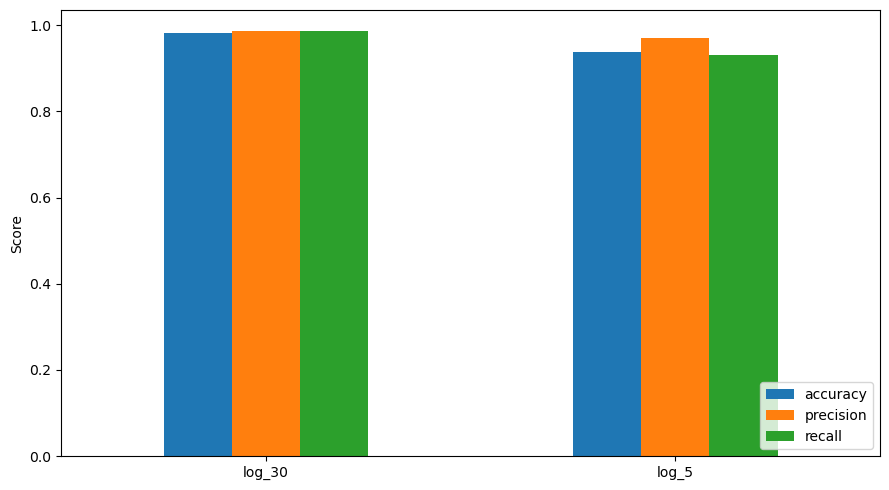

In [9]:
comparison.T.plot(kind="bar", figsize=(9, 5), rot=0)
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

2. Using `logreg.predict_proba(X_test_scaled)`, find the threshold (steps of 0.05, 0.05 to 0.95) that maximizes recall on the malignant class (`pos_label=0`) while keeping its precision above 0.90. Report both metrics, and plot precision and recall against threshold, marking the one you chose. Then plot the confusion matrix at that threshold next to the Decision Tree's (`tree`, above): which one makes more false negatives on malignant?

Best threshold: 0.4
Precision: 0.9111111111111111
Recall: 0.9761904761904762


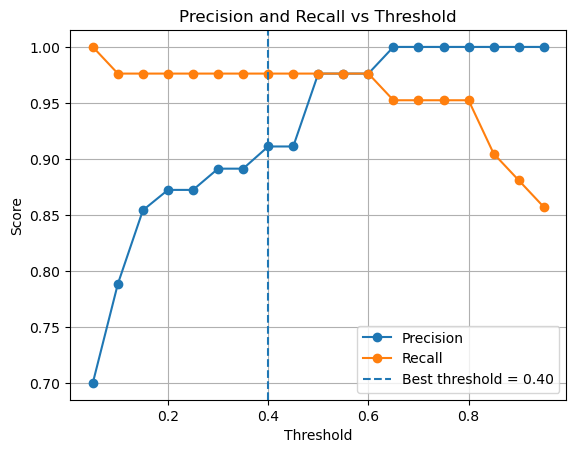

In [ ]:
thresholds = np.arange(0.05, 1.00, 0.05)

precisions = []
recalls = []

best_threshold = None
best_precision = 0
best_recall = 0

for i in thresholds:

    y_pred_Malignant = (
        log_model_30.predict_proba(x_test_scaled)[:, 0] < i
    )

    precision = precision_score(
        y_test,
        y_pred_Malignant,
        pos_label=0
    )

    recall = recall_score(
        y_test,
        y_pred_Malignant,
        pos_label=0
    )

    precisions.append(precision)
    recalls.append(recall)

    if precision > 0.90 and recall > best_recall:
        best_threshold = i
        best_precision = precision
        best_recall = recall

print("Best threshold:", best_threshold)
print("Precision:", best_precision)
print("Recall:", best_recall)


# Plot
plt.plot(thresholds, precisions, marker='o', label='Precision')
plt.plot(thresholds, recalls, marker='o', label='Recall')

plt.axvline(
    best_threshold,
    linestyle='--',
    label=f'Best threshold = {best_threshold:.2f}'
)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid()
plt.show()

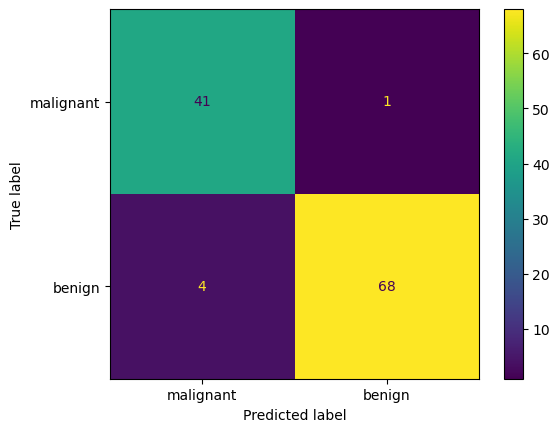

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_Malignant_best=log_model_30.predict_proba(x_test_scaled)[:, 0] < best_threshold

cm=confusion_matrix(y_test,y_pred_Malignant_best)
ConfusionMatrixDisplay(cm,display_labels=data.target_names).plot()

In [13]:
false_negative_logreg = cm[0, 1]

print("False Negatives:", false_negative_logreg)

False Negatives: 1


In [14]:
tree=DecisionTreeClassifier(max_depth=4,random_state=42)
tree.fit(x_train_scaled,y_train)
y_pred_tree=tree.predict(x_test_scaled)

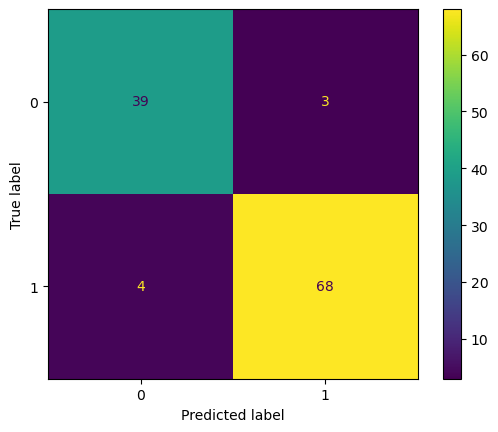

In [15]:
cm_tree=confusion_matrix(y_test,y_pred_tree)
ConfusionMatrixDisplay(cm_tree).plot()

3. Repeat notebook 3's k-selection restricted to `metric="manhattan"`. Does the best `k` change? Does the best CV accuracy? Plot CV accuracy against `k`, same style as notebook 3's elbow curve.

In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1, 31)
cv_scores = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k,metric="manhattan")
    scores = cross_val_score(model, x_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

best_k = k_values[int(np.argmax(cv_scores))]
best_k

4

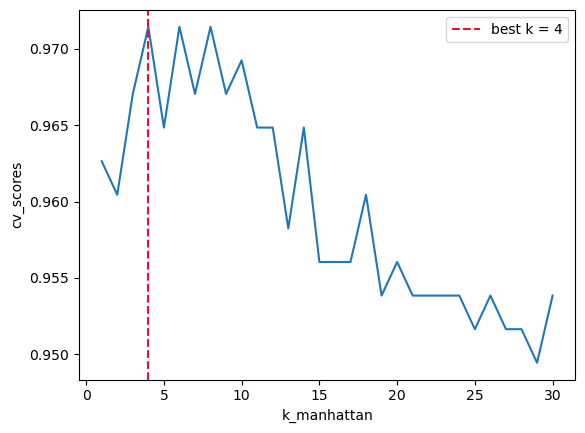

In [17]:
plt.plot(list(k_values),cv_scores)
plt.axvline(best_k, color="crimson", linestyle="--", label=f"best k = {best_k}")
plt.xlabel("k_manhattan")
plt.ylabel("cv_scores")
plt.legend()
plt.show()

4. Using `cross_val_score`, find the best `max_depth` for the Decision Tree among `[2, 3, 4, 5, 6, 8, 10, None]` with `cv=5`. Compare to the fixed `max_depth=4` tree used above. Plot CV accuracy against `max_depth` (treat `None` as, say, 12 so it fits on the axis).

In [18]:
max_depths=[2, 3, 4, 5, 6, 8, 10, None]
cv_score=[]
for max_depth in max_depths:
    model_tree=DecisionTreeClassifier(max_depth=max_depth,random_state=42)
    score=cross_val_score(model_tree,x_train_scaled,y_train,cv=5,scoring="accuracy")
    cv_score.append(score.mean())
best_max_depth = max_depths[int(np.argmax(cv_score))]
best_max_depth    

4

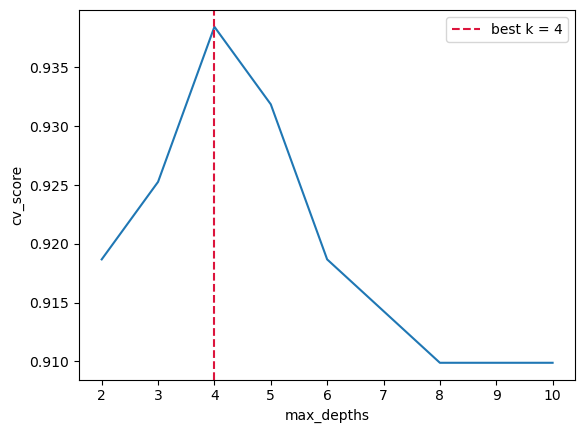

In [19]:
plt.plot(max_depths,cv_score)
plt.axvline(best_max_depth, color="crimson", linestyle="--", label=f"best k = {best_max_depth}")
plt.xlabel("max_depths")
plt.ylabel("cv_score")
plt.legend()
plt.show()

5. Using the imbalanced data from notebook 2 section 8.2, train a real `LogisticRegression` (not `DummyClassifier`). Generate matching features, for example `X_imbalanced = np.random.default_rng(42).normal(size=(1000, 2))` related to `y_imbalanced`. Does it beat the "always healthy" baseline on recall? By how much? Plot both models' confusion matrices side by side.

In [45]:
y_imbalanced = np.array([0] * 950 + [1] * 50)
X_imbalanced = np.random.default_rng(42).normal(size=(1000, 2))

log_imbalanced=LogisticRegression().fit(X_imbalanced,y_imbalanced)
#......................

6. Change `k` from 5 to 3 in notebook 3's toy example and recompute the vote by hand. Does the prediction change?

In [34]:
X_toy = np.array([
    [1.0, 2.0], [1.5, 1.8], [1.2, 2.6], [2.0, 2.2], [0.8, 1.5],
    [4.5, 4.0], [5.0, 3.5], [4.2, 4.8], [5.5, 4.2], [4.8, 3.2],
])
y_toy = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])  # 0 = malignant-like, 1 = benign-like
query = np.array([3.0, 3.0])

distances = np.sqrt(((X_toy - query) ** 2).sum(axis=1))
order = np.argsort(distances)

k = 3
nearest_k_labels = y_toy[order[:k]]
vote = np.bincount(nearest_k_labels).argmax()
print("Votes among k nearest neighbors:", np.bincount(nearest_k_labels))
print("Predicted class:", vote)


Votes among k nearest neighbors: [1 2]
Predicted class: 1


7. Add one more day to the Play Tennis table (notebook 4) with weather and label of your choice, refit, and re-plot. Did the tree structure change?

In [35]:
tennis = pd.DataFrame({
    "Outlook":  ["Sunny", "Sunny", "Overcast", "Rain", "Rain", "Rain",
                 "Overcast", "Sunny", "Overcast", "Rain","Overcast"],
    "Humidity": ["High", "High", "High", "High", "Normal", "Normal",
                 "Normal", "Normal", "Normal", "High","Normal"],
    "Wind":     ["Weak", "Strong", "Weak", "Weak", "Weak", "Strong",
                 "Strong", "Weak", "Weak", "Strong","Weak"],
    "Play":     ["No", "No", "Yes", "Yes", "Yes", "No",
                 "Yes", "Yes", "Yes", "No","Yes"],
})
tennis

,Outlook,Humidity,Wind,Play
0,Sunny,High,Weak,No
1,Sunny,High,Strong,No
2,Overcast,High,Weak,Yes
3,Rain,High,Weak,Yes
4,Rain,Normal,Weak,Yes
5,Rain,Normal,Strong,No
6,Overcast,Normal,Strong,Yes
7,Sunny,Normal,Weak,Yes
8,Overcast,Normal,Weak,Yes
9,Rain,High,Strong,No


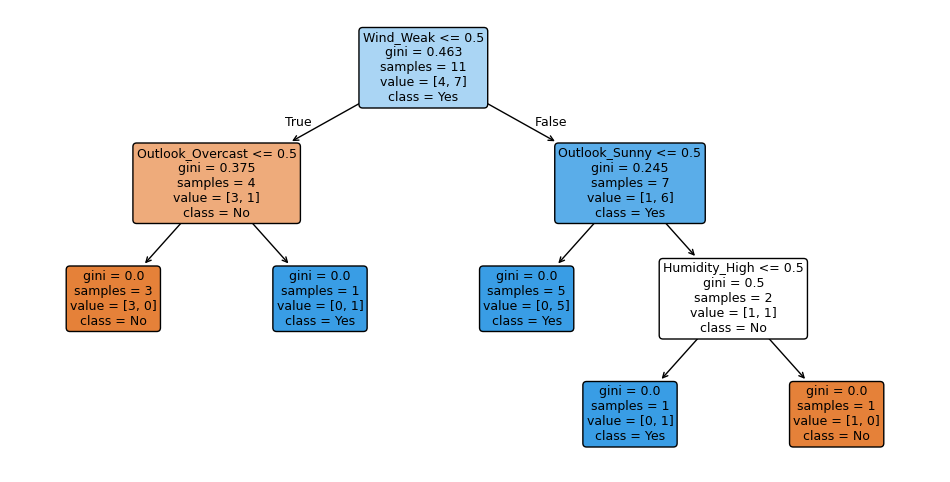

In [44]:
from sklearn.tree import plot_tree
x_tennis = pd.get_dummies(tennis.drop(columns="Play"))
y_tennis = (tennis["Play"] == "Yes").astype(int)

tree_tennis=DecisionTreeClassifier(max_depth=3).fit(x_tennis,y_tennis)
fig, ax = plt.subplots(figsize=(12, 6))
plot_tree(tree_tennis, feature_names=x_tennis.columns, class_names=["No", "Yes"],
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.show()